In [1]:
import numpy as np
import networkx as nx
import itertools

from snn import Network, Population, Projection, Port, Pack
from snn.model import IN, LIF, PSP

In [2]:
# Helper function for edges (use CSA for this?)
def get_edges(prob, num_s, num_t, same):
    edges = set()
    assert 0.0 <= prob <= 1.0, f"Probability {prob} is not between 0.0 and 1.0"
    num = int(prob * num_s * num_t)
    while len(edges) < num:
        s = np.random.randint(num_s)
        t = np.random.randint(num_t)
        # no self connections
        if (not same) or (s != t):
            edges.add((s,t))
    return list(edges)

In [3]:
class ResEI(Network):
    def __init__(self, res_e_size=800, res_i_size=200, prob=0.1):
        super().__init__()
        self.res_e_size = res_e_size
        self.res_i_size = res_i_size
        self.prob = prob

    def build(self):
        # Populations
        self.res_e = Population(LIF(), self.res_e_size)
        self.res_i = Population(LIF(), self.res_i_size)

        # Connections
        self.ee = Projection(self.res_e, self.res_e, PSP(),
                             get_edges(self.prob, self.res_e_size, self.res_e_size, True))
        self.ei = Projection(self.res_e, self.res_i, PSP(),
                             get_edges(self.prob, self.res_e_size, self.res_i_size, False))
        self.ie = Projection(self.res_i, self.res_e, PSP(),
                             get_edges(self.prob, self.res_i_size, self.res_e_size, False))
        self.ii = Projection(self.res_i, self.res_i, PSP(),
                             get_edges(self.prob, self.res_i_size, self.res_i_size, True))
        
        return

In [4]:
net = Network()

num_res = 3
res_e_size = 40
res_i_size = 10

net.res = [ResEI(res_e_size,res_i_size) for _ in range(num_res)]

net.re__re = [Projection(net.res[i].res_e, net.res[j].res_e, PSP(weight=0.01),
                     get_edges(0.01, res_e_size, res_e_size, False))
              for i, j in itertools.product(range(num_res), range(num_res)) if i != j]

info: adding list of networks


In [5]:
net.build()

info: building res[0]
info: building res[1]
info: building res[2]
info: flattening network topology


In [6]:
print(net)

(edge) re__re[0]: (node) res[0].res_e -> (node) res[1].res_e
(edge) re__re[1]: (node) res[0].res_e -> (node) res[2].res_e
(edge) re__re[2]: (node) res[1].res_e -> (node) res[0].res_e
(edge) re__re[3]: (node) res[1].res_e -> (node) res[2].res_e
(edge) re__re[4]: (node) res[2].res_e -> (node) res[0].res_e
(edge) re__re[5]: (node) res[2].res_e -> (node) res[1].res_e
(node) res[0].res_e
(node) res[0].res_i
(edge) res[0].ee: (node) res[0].res_e -> (node) res[0].res_e
(edge) res[0].ei: (node) res[0].res_e -> (node) res[0].res_i
(edge) res[0].ie: (node) res[0].res_i -> (node) res[0].res_e
(edge) res[0].ii: (node) res[0].res_i -> (node) res[0].res_i
(node) res[1].res_e
(node) res[1].res_i
(edge) res[1].ee: (node) res[1].res_e -> (node) res[1].res_e
(edge) res[1].ei: (node) res[1].res_e -> (node) res[1].res_i
(edge) res[1].ie: (node) res[1].res_i -> (node) res[1].res_e
(edge) res[1].ii: (node) res[1].res_i -> (node) res[1].res_i
(node) res[2].res_e
(node) res[2].res_i
(edge) res[2].ee: (node) r

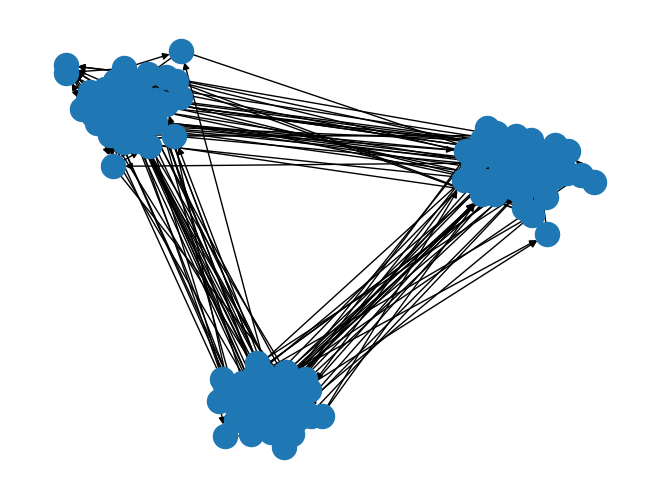

In [7]:
nx.draw(net._graph)